<a href="https://colab.research.google.com/github/proteinovayas13/My_works/blob/main/%D0%A4%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Сколько исходной информации описывают 3 фактора при использовании метода главных компонент?
# Какие три основных переменных вносят вклад в третий фактор при реализации PCA?
# Какой вклад вносит третий фактор при использовании факторного анализа?
# Какие три основных переменных вносят вклад в третий фактор при реализации факторного анализа?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('StressLevelDataset.csv')
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [6]:
total_student = len(df)
print(f'В датасете = {total_student} опрощенных студентов')

В датасете = 1100 опрощенных студентов


In [7]:
#проверим, есть ли у нас пропущенные значения
df.isnull().sum()

,0
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0


In [8]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


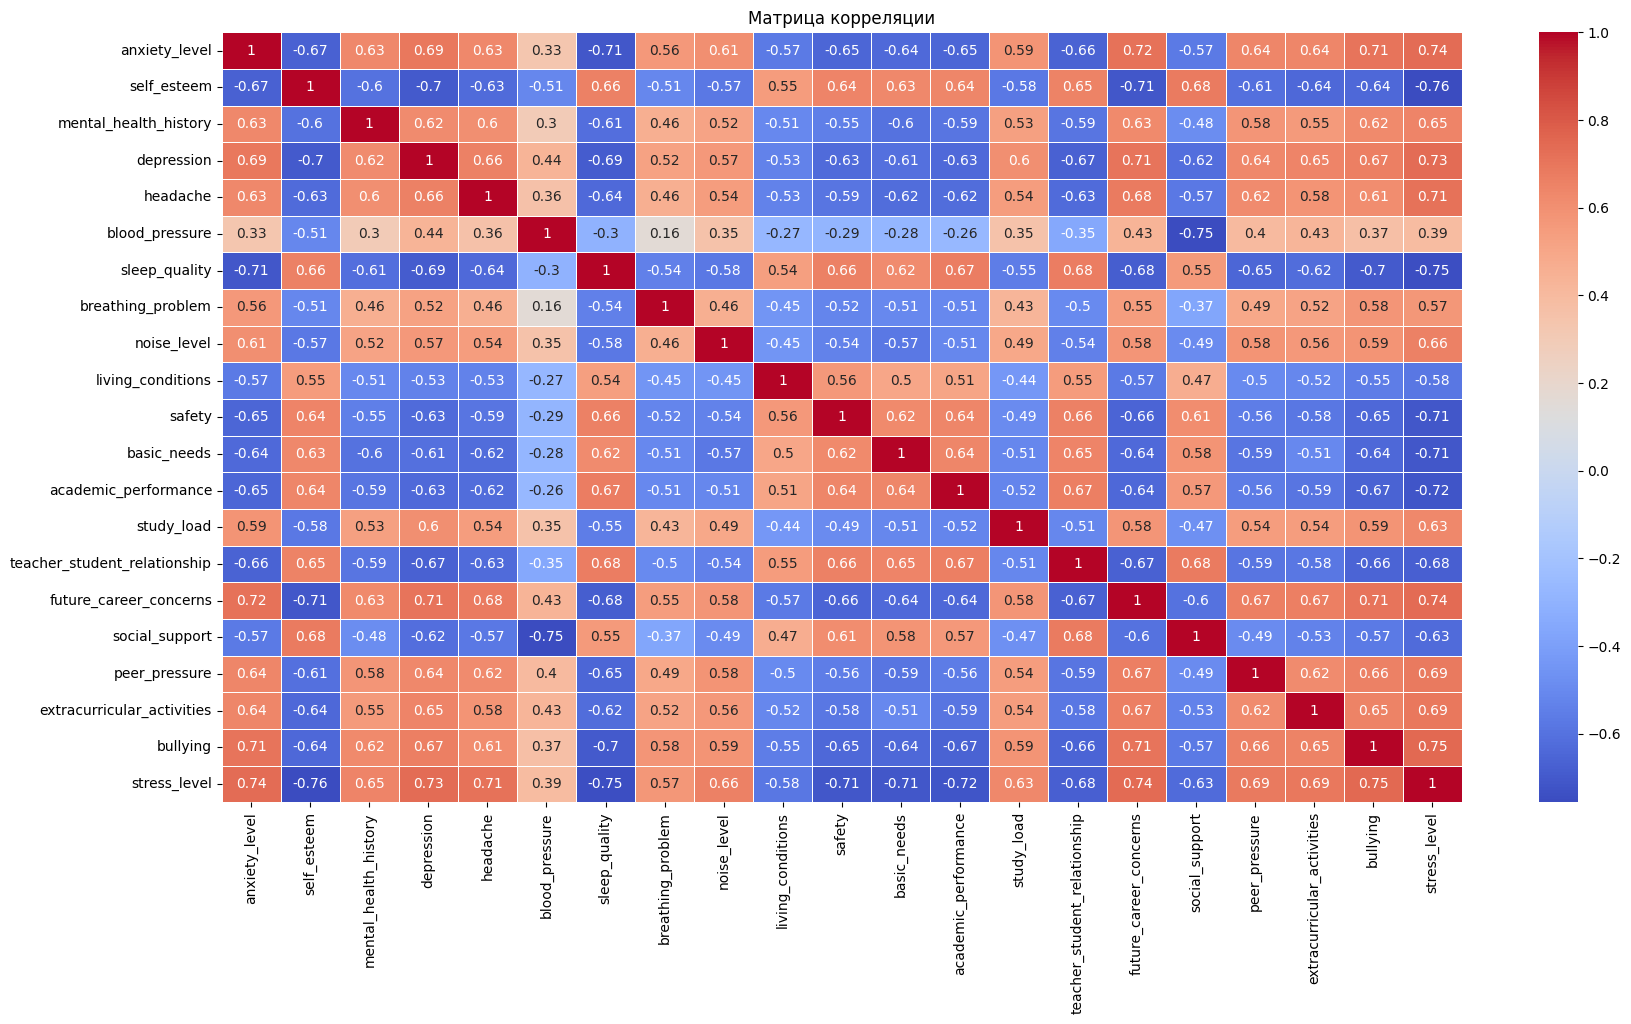

In [11]:
correlation_matrix = df[['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляции')
plt.show()


In [12]:
eigenvalues, _ = np.linalg.eig(correlation_matrix)

print("Собственные числа:", eigenvalues)


Собственные числа: [12.70294466  1.19861812  0.69394774  0.10226818  0.59529366  0.55921525
  0.17489164  0.5262102   0.47423875  0.45801512  0.23296411  0.4063027
  0.26646354  0.27322623  0.28248605  0.38595835  0.36433672  0.34838292
  0.3287309   0.31322604  0.31227913]


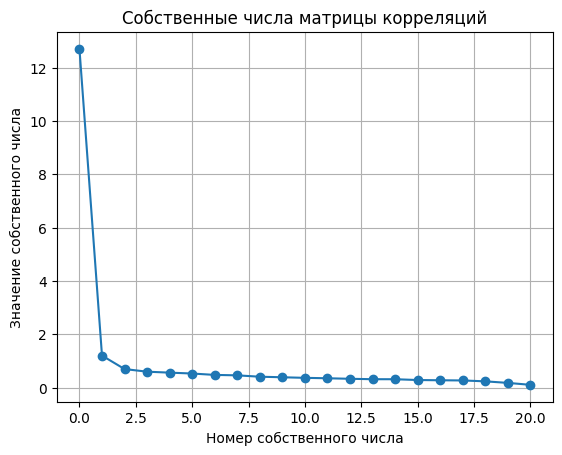

In [13]:
import matplotlib.pyplot as plt
eigenvalues_sorted = np.sort(eigenvalues)[::-1]

plt.plot(eigenvalues_sorted, marker='o')
plt.title('Собственные числа матрицы корреляций')
plt.xlabel('Номер собственного числа')
plt.ylabel('Значение собственного числа')
plt.grid(True)
plt.show()

In [16]:
def manual_pca(data, num_components):
    mean_vector = np.mean(data, axis=0)
    centered_data = data - mean_vector

    covariance_matrix = np.cov(centered_data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    selected_eigenvectors = eigenvectors[:, :num_components]
    return selected_eigenvectors

    def interpret_factors(factor_loadings, variable_names):
      num_factors = factor_loadings.shape[1]

      for i in range(num_factors):
        for j in range(factor_loadings.shape[1]):
          print(f"  {variable_names[j]}: {factor_loadings[j, i]}")
          print()
          print(f"Фактор {i+1}:")

In [18]:
# 1)Сколько исходной информации описывают 3 фактора при использовании метода главных компонент?
num_factors = 3
factor_loadings = manual_pca(df, num_factors)
print('Факторные нагрузки')
print(factor_loadings)

Факторные нагрузки
[[ 0.40752691 -0.26619209 -0.82199701]
 [-0.6587742  -0.72531153 -0.13667359]
 [ 0.02769293 -0.00862385 -0.01391479]
 [ 0.54765907 -0.62747258  0.52921404]
 [ 0.08155379 -0.02931877 -0.02087664]
 [ 0.03344338  0.0217635   0.03071882]
 [-0.0956977   0.03838293  0.05051865]
 [ 0.06682973 -0.02543169 -0.05061092]
 [ 0.06954292 -0.01796781 -0.04790255]
 [-0.05550396  0.00855119  0.03546364]
 [-0.08156888  0.01287518  0.04309575]
 [-0.08140027  0.01143555  0.04509187]
 [-0.08207565  0.0177412   0.04024621]
 [ 0.06964371 -0.02464206 -0.01920763]
 [-0.0830388   0.02597652  0.02771074]
 [ 0.09830419 -0.0195791  -0.04067976]
 [-0.05993027 -0.01250494 -0.00604975]
 [ 0.08077111 -0.03205772 -0.03890824]
 [ 0.08250638 -0.02039179 -0.02676748]
 [ 0.09236448 -0.03873304 -0.06628805]
 [ 0.05523543 -0.00653635 -0.01928026]]


In [19]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=f1ed049606c4c9d4583a8a1ad75c2704deb8bcbc76c5ca466ac7fa4a336aa237
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [21]:
#2Какие три основных переменных вносят вклад в третий фактор при реализации PCA?

def highlight_max(s):
    is_large = s.nlargest(10).values
    return ['background-color: palevioletred' if v in is_large else '' for v in s]

fa_load_pca = pd.DataFrame(factor_loadings,index=df.columns)
fa_load_pca.sort_values(by=2,ascending=False).style.apply(highlight_max)

,0,1,2
depression,0.547659,-0.627473,0.529214
sleep_quality,-0.095698,0.038383,0.050519
basic_needs,-0.081400,0.011436,0.045092
safety,-0.081569,0.012875,0.043096
academic_performance,-0.082076,0.017741,0.040246
living_conditions,-0.055504,0.008551,0.035464
blood_pressure,0.033443,0.021764,0.030719
teacher_student_relationship,-0.083039,0.025977,0.027711
social_support,-0.059930,-0.012505,-0.006050
mental_health_history,0.027693,-0.008624,-0.013915


In [27]:
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
pca = PCA(n_components=3)

In [23]:
pca.fit_transform(df)
eigenvectors = pca.components_
ps = pd.DataFrame(eigenvectors.T, index=df.columns)

ps.sort_values(by=2,ascending=False).style.apply(highlight_max)

,0,1,2
anxiety_level,-0.407527,0.266192,0.821997
self_esteem,0.658774,0.725312,0.136674
bullying,-0.092364,0.038733,0.066288
breathing_problem,-0.066830,0.025432,0.050611
noise_level,-0.069543,0.017968,0.047903
future_career_concerns,-0.098304,0.019579,0.040680
peer_pressure,-0.080771,0.032058,0.038908
extracurricular_activities,-0.082506,0.020392,0.026767
headache,-0.081554,0.029319,0.020877
stress_level,-0.055235,0.006536,0.019280


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


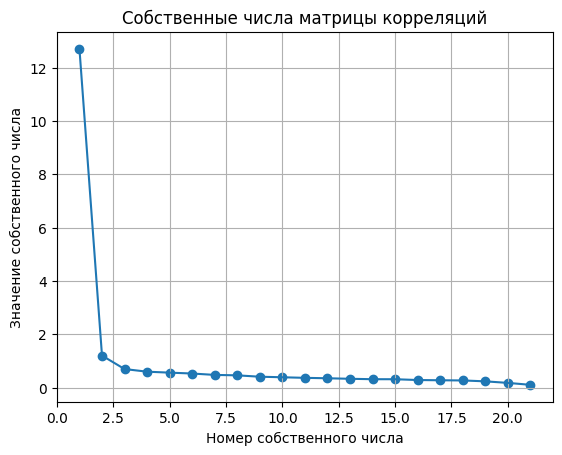

In [28]:
n = df.shape[1] # n - количество переменных (столбцов) в нашем наборе данных

fa = FactorAnalyzer(rotation = None,impute = "drop",n_factors=n)

fa.fit(df)

ev,_ = fa.get_eigenvalues()

plt.scatter(range(1,n+1),ev)

plt.plot(range(1,n+1),ev)
plt.title('Собственные числа матрицы корреляций')
plt.xlabel('Номер собственного числа')
plt.ylabel('Значение собственного числа')
plt.grid()

In [29]:
print(ev)

[12.70294466  1.19861812  0.69394774  0.59529366  0.55921525  0.5262102
  0.47423875  0.45801512  0.4063027   0.38595835  0.36433672  0.34838292
  0.3287309   0.31322604  0.31227913  0.28248605  0.27322623  0.26646354
  0.23296411  0.17489164  0.10226818]


In [31]:
fa = FactorAnalyzer(n_factors=3,rotation='varimax')

fa.fit(df)
fa_load = pd.DataFrame(fa.loadings_,index=df.columns)
fa_load

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,0,1,2
anxiety_level,0.748403,-0.347178,0.168029
self_esteem,-0.643125,0.387768,-0.365097
mental_health_history,0.667234,-0.298484,0.147217
depression,0.700352,-0.337842,0.287556
headache,0.656667,-0.357206,0.218399
blood_pressure,0.190400,-0.081616,0.975776
sleep_quality,-0.725548,0.383791,-0.134608
breathing_problem,0.614773,-0.253302,0.026172
noise_level,0.634912,-0.235935,0.217176
living_conditions,-0.562538,0.328987,-0.139919


In [37]:
#3)Какой вклад вносит третий фактор при использовании факторного анализа?(0.06741313)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

n_components = min(df.shape[0], df.shape[1])
pca = PCA(n_components=n_components)
pca.fit(df_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)

[0.60490213 0.05707705 0.03304513 0.02834732 0.0266293  0.02505763
 0.0225828  0.02181024 0.01934775 0.01837897 0.01734937 0.01658966
 0.01565385 0.01491553 0.01487043 0.01345172 0.01301077 0.01268874
 0.01109353 0.00832817 0.00486991]


In [38]:
#4)Какие три основных переменных вносят вклад в третий фактор при реализации факторного анализа?
fa_load.sort_values(by=2,ascending=False).style.apply(highlight_max)

,0,1,2
blood_pressure,0.190400,-0.081616,0.975776
depression,0.700352,-0.337842,0.287556
extracurricular_activities,0.705757,-0.198073,0.284589
future_career_concerns,0.732865,-0.329283,0.271701
peer_pressure,0.735368,-0.175589,0.246785
study_load,0.630861,-0.198484,0.227586
stress_level,0.780862,-0.383938,0.224566
headache,0.656667,-0.357206,0.218399
noise_level,0.634912,-0.235935,0.217176
bullying,0.746467,-0.323859,0.193550
